# 6 - Hierarchical Clustering

## Imports

In [90]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [94]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa
from Importables import clustering_utils as c

## Test Functions

In [13]:
# def make_chord_test(pitches):
#     result = []
#     for pitch in pitches:
#         result.append(m21.pitch.Pitch(pitch))

#     return result

In [14]:
# def get_chord_distance_semitones(chord1, chord2):
#     distance = 0
#     for note1 in chord1:
#         for note2 in chord2:
#             intvl = m21.interval.Interval(noteStart=note1, noteEnd=note2)
#             semitones = intvl.semitones % 24
#             distance += semitones 
#     return distance

In [15]:
# def get_chord_distance_linefifths(chord1, chord2):
#     distance = 0
#     for note1 in chord1:
#         for note2 in chord2:
#             note1tpc = pa.get_tpc(note1)
#             note2tpc = pa.get_tpc(note2)
#             distance += abs(note1tpc - note2tpc)
#     return distance

In [16]:
# def transpose_chord(chord):
    
#     if not isinstance(chord, m21.chord.Chord):
#         chord = m21.chord.Chord(chord)
        
#     transposed_chords = []
    
#     for semitones in range(1, 12):
#         intvl = interval.Interval(semitones)
#         transposed = chord.transpose(intvl)
#         transposed_chords.append(transposed)
        
#     return transposed_chords

In [17]:
# ### HOW TO HANDLE MIN_DISTANCE = 0 ????
# def get_norm_distance(chord1, chord2, method="semitones"):
#     if method not in ["semitones", "line of fifths"]:
#         raise ValueError("method must be 'semitones' or 'line of fifths'")
        
#     min_distance = float('inf')
#     transposed_chords = transpose_chord(chord2)

#     for chord in transposed_chords:

#         if method == 'semitones':
#             distance = get_chord_distance_semitones(chord1, chord)
#         if method == 'line of fifths':
#            distance = get_chord_distance_linefifths(chord1, chord) 
        
#         if (distance < min_distance) and (min_distance != 0):
#             min_distance = distance

#     if method == 'semitones':
#         result = get_chord_distance_semitones(chord1, chord2) / min_distance 
#     if method == 'line of fifths':
#         result = get_chord_distance_linefifths(chord1, chord2) / min_distance     

#     return result

In [19]:
# C = make_chord_test(['C4', 'E4', 'G4'])
# Cm = make_chord_test(['C4', 'E4-', 'G4'])
# G = make_chord_test(['G4', 'B4', 'D4'])
# F = make_chord_test(['F4', 'A4', 'C4'])
# Cdom7 = make_chord_test(['C4', 'E4', 'G4', 'B-4'])

In [20]:
# chords = [(C, Cm),(C, G),(C, F),(G, F),(C, Cdom7)]

# for chord1, chord2 in chords:
#     chord1_name  = m21.chord.Chord(chord1).pitchedCommonName
#     chord2_name  = m21.chord.Chord(chord2).pitchedCommonName
#     print(f"{chord1_name} vs {chord2_name} semitone distance: " + str(get_chord_distance_semitones(chord1, chord2)))
#     print(f"{chord1_name} vs {chord2_name} line of fifths distance: " + str(get_chord_distance_linefifths(chord1, chord2)))

C-major triad vs C-minor triad semitone distance: 93
C-major triad vs C-minor triad line of fifths distance: 23
C-major triad vs G-major triad semitone distance: 75
C-major triad vs G-major triad line of fifths distance: 19
C-major triad vs F-major triad semitone distance: 81
C-major triad vs F-major triad line of fifths distance: 19
G-major triad vs F-major triad semitone distance: 126
G-major triad vs F-major triad line of fifths distance: 24
C-major triad vs C-dominant seventh chord semitone distance: 91
C-major triad vs C-dominant seventh chord line of fifths distance: 27


## Test: Shapons Vindaloo - Snarky Puppy

In [96]:
metadata = g.load_metadata()

In [104]:
notes = g.load_notes(metadata.iloc[[0]], keys=True)

In [110]:
notes_C = pa.transpose_to_C(notes)

In [112]:
notes_vectors = c.get_clustering_data(notes_C)

# Drop duplicate measures
subset_cols = [col for col in notes_vectors.columns if col != 'mc']
notes_no_dups = notes_vectors.drop_duplicates(subset=subset_cols)
notes_no_dups

,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,mc,recording_year,artist
0,0.0,0.0,0.666667,0.0,0.000000,0.000000,0.0,0.000000,0.333333,0.0,0.0000,0.0,0.0,0.0,0.0,1,2015.0,Snarky Puppy
1,0.0,0.0,0.000000,0.0,0.000000,0.166667,0.0,0.666667,0.166667,0.0,0.0000,0.0,0.0,0.0,0.0,2,2015.0,Snarky Puppy
2,0.0,0.0,0.000000,0.0,0.000000,0.333333,0.0,0.666667,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,3,2015.0,Snarky Puppy
3,0.0,0.0,0.333333,0.0,0.000000,0.333333,0.0,0.333333,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,4,2015.0,Snarky Puppy
6,0.0,0.0,0.444444,0.0,0.000000,0.222222,0.0,0.222222,0.111111,0.0,0.0000,0.0,0.0,0.0,0.0,7,2015.0,Snarky Puppy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.0,0.0,0.090909,0.0,0.090909,0.181818,0.0,0.545455,0.090909,0.0,0.0000,0.0,0.0,0.0,0.0,128,2015.0,Snarky Puppy
130,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,131,2015.0,Snarky Puppy
131,0.0,0.0,0.000000,0.0,0.000000,0.625000,0.0,0.062500,0.000000,0.0,0.3125,0.0,0.0,0.0,0.0,134,2015.0,Snarky Puppy
132,0.0,0.0,0.000000,0.0,0.000000,0.125000,0.0,0.875000,0.000000,0.0,0.0000,0.0,0.0,0.0,0.0,135,2015.0,Snarky Puppy


In [120]:
X = notes_no_dups.drop(columns=['mc', 'recording_year', 'artist']).to_numpy()
# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

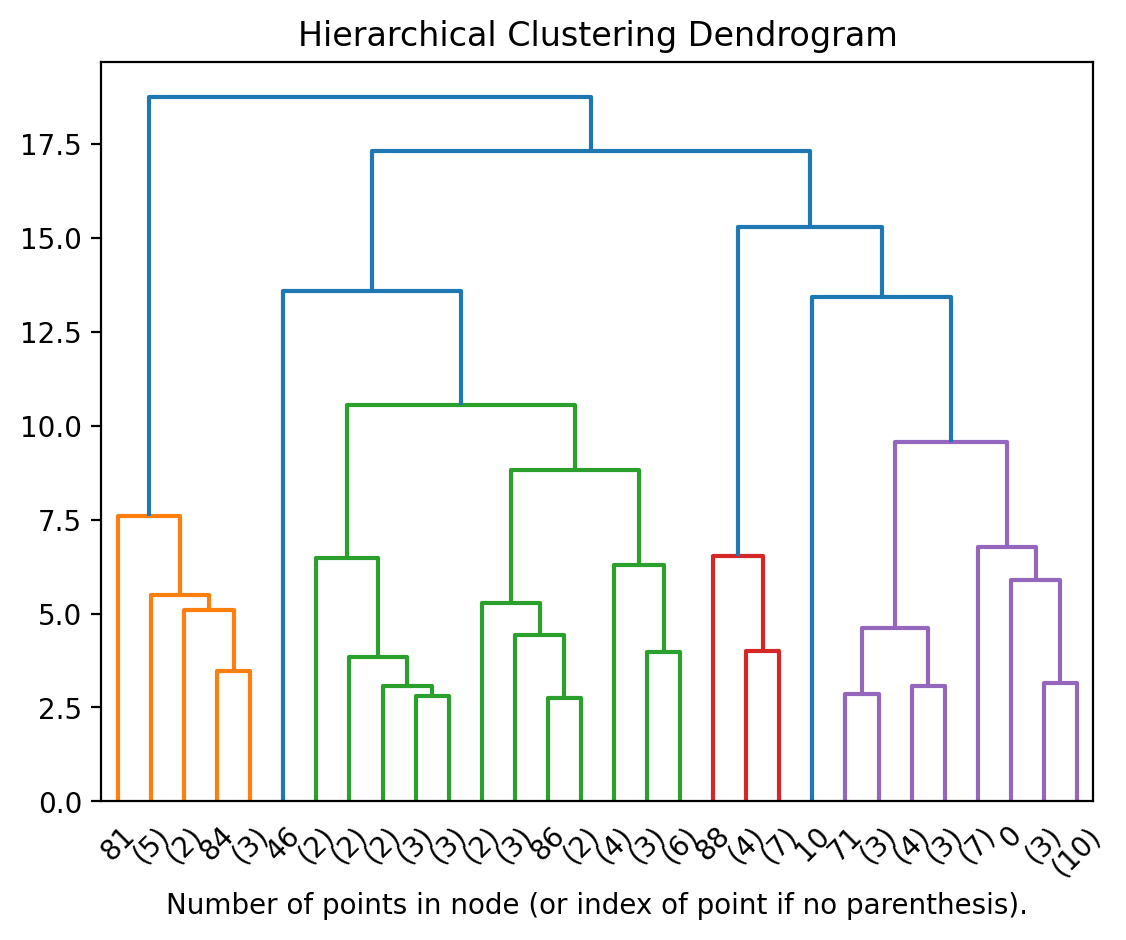

In [122]:

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X_scaled)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top 30 clusters of the dendrogram
dendro = c.plot_dendrogram(model, truncate_mode="lastp", p=30
    )
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.xticks(rotation=45)
#plt.axhline(y = 0.75, color = 'r', linestyle = '-')
plt.show()

In [128]:
n_clusters = 7
clustering = AgglomerativeClustering(n_clusters, linkage='ward').fit(X_scaled)
clustering

AgglomerativeClustering(n_clusters=7)

In [132]:
labels = clustering.labels_
# Assign cluster label to each measure
notes_no_dups.loc[:, 'cluster'] = labels

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_90520/60442461.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  notes_no_dups.loc[:, 'cluster'] = labels


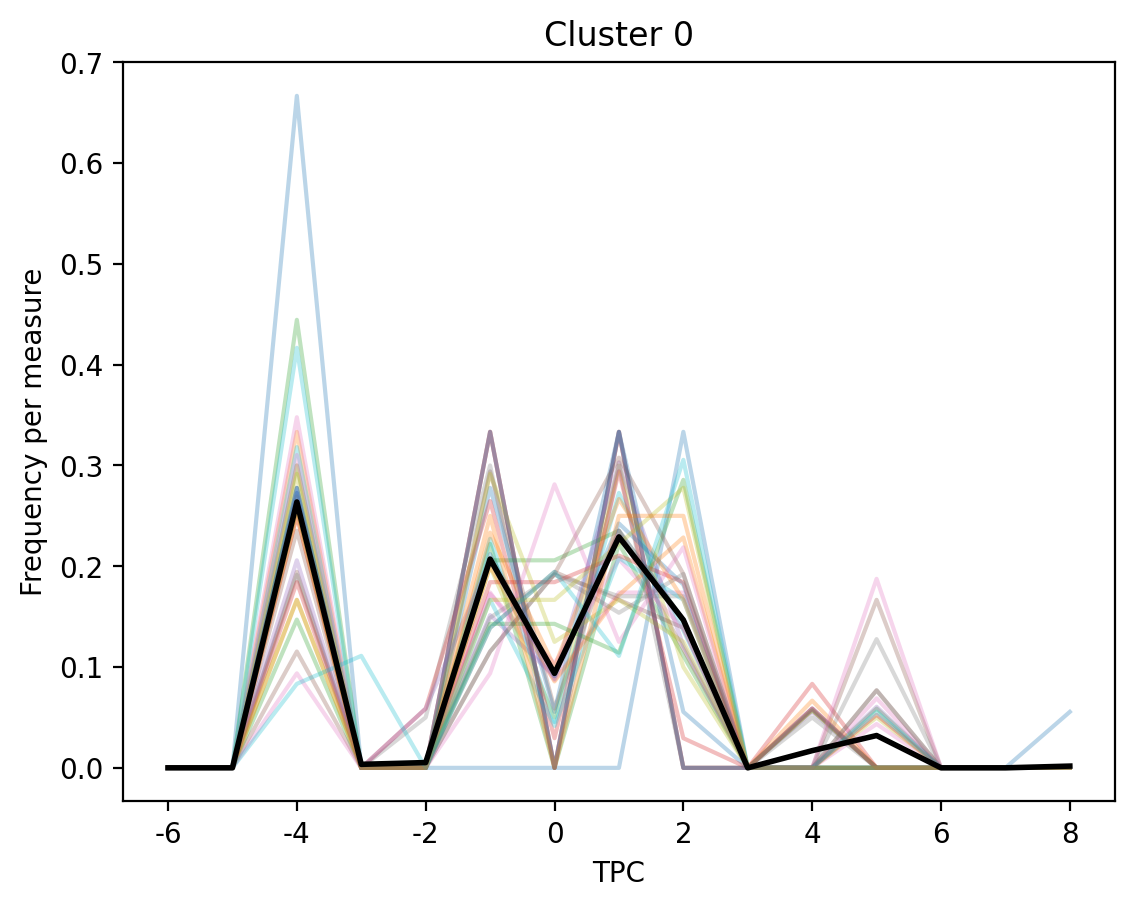

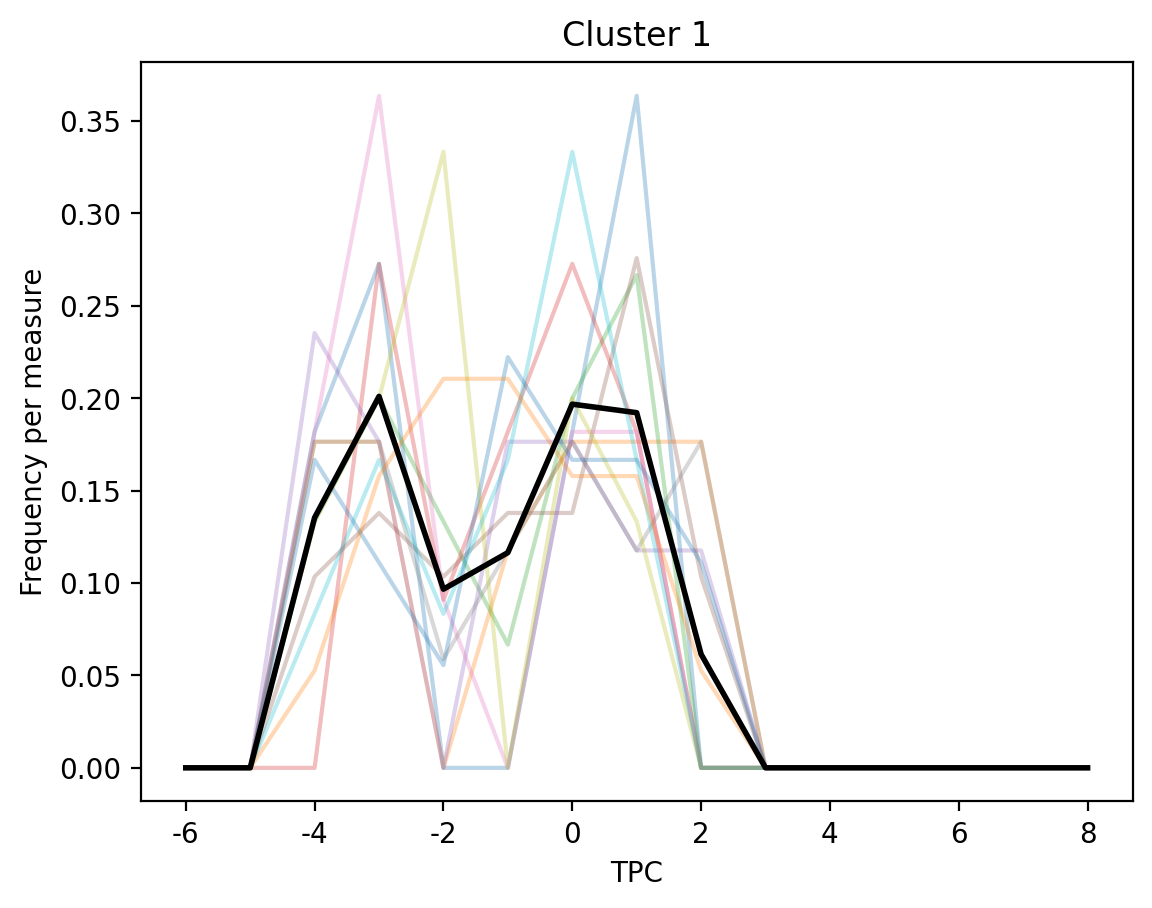

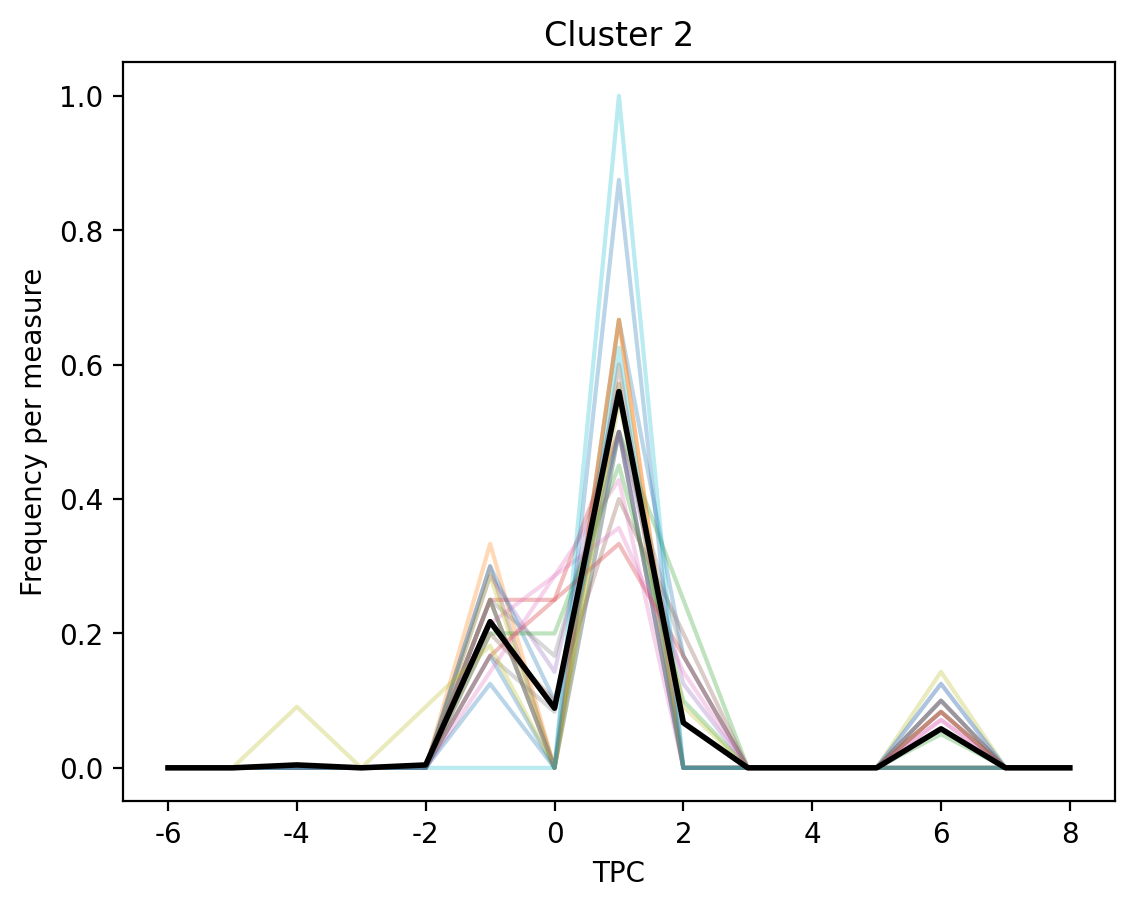

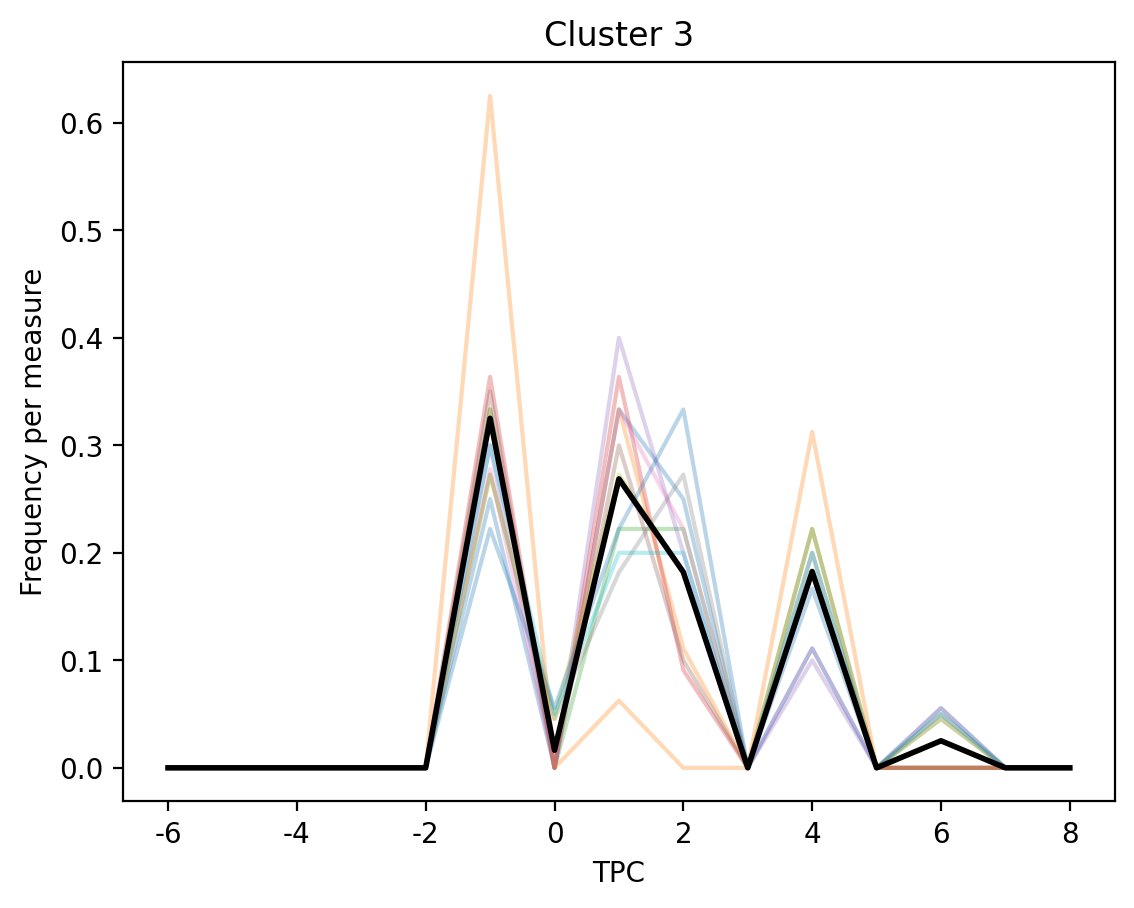

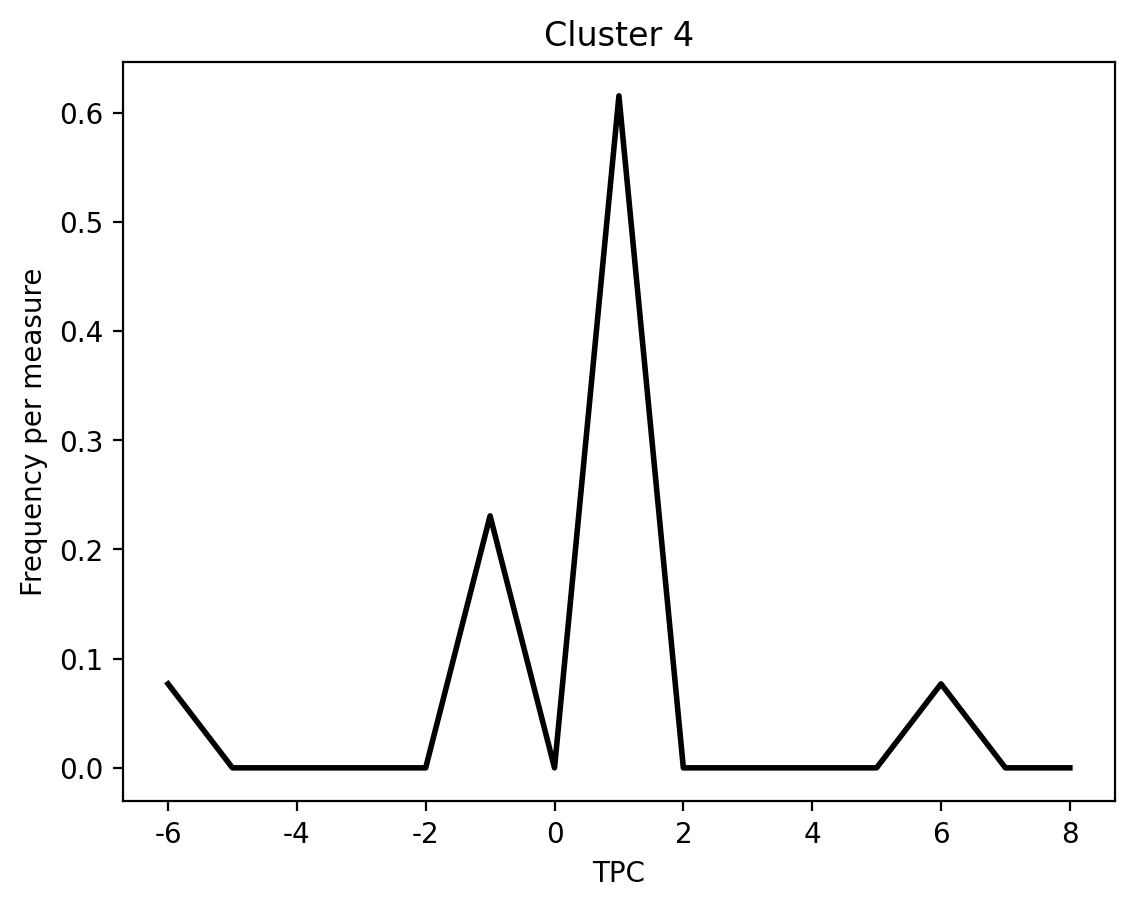

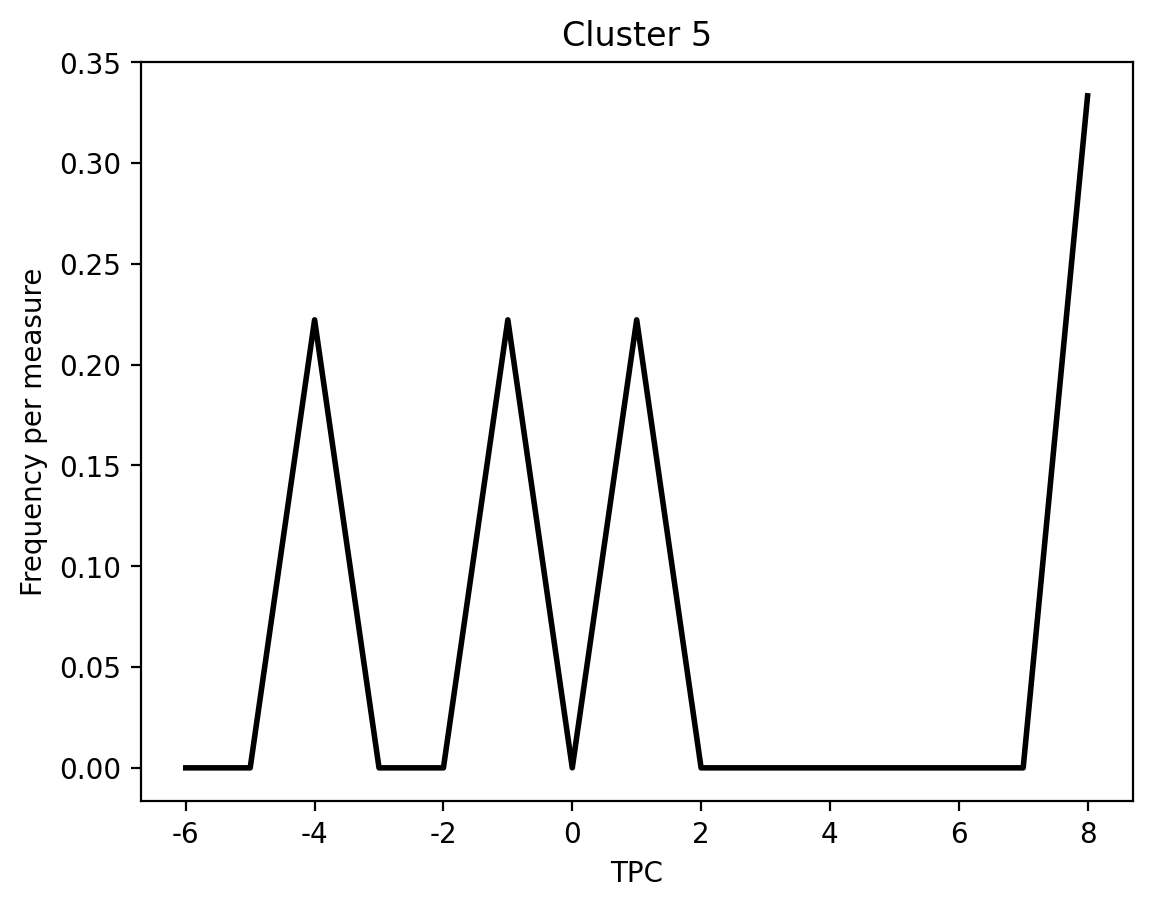

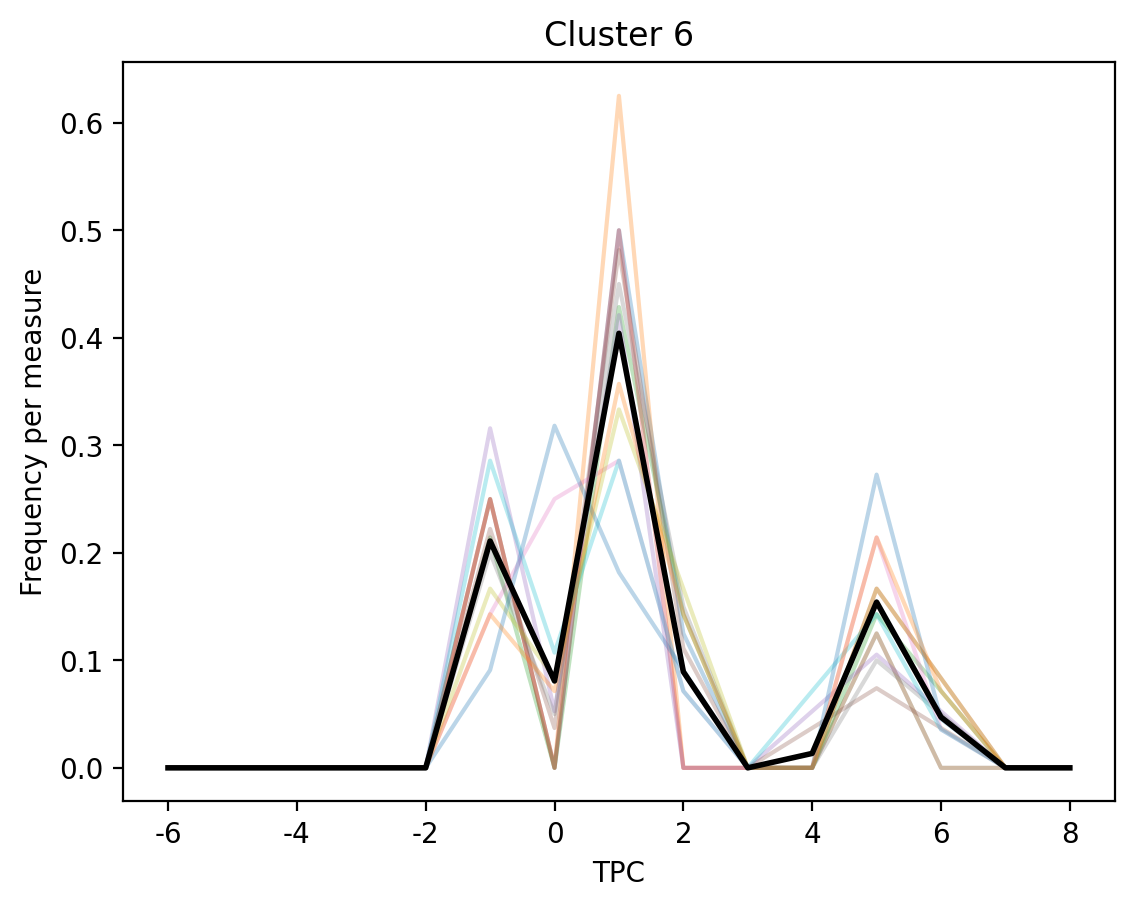

In [134]:
#Plot clusters 
for key in range(n_clusters):
    subset = notes_no_dups[notes_no_dups['cluster'] == key]
    
    # Drop cluster column, set index to mc
    plot_df = subset.drop(columns=['cluster', 'recording_year', 'artist']).set_index('mc')
    
    # Plot all vectors (each row → one line)
    plot_df.T.plot(legend=False, alpha=0.3)  # faded lines for individual series
    
    # Compute and plot the average vector
    avg_vector = plot_df.mean(axis=0)
    avg_vector.plot(color="black", linewidth=2, label="Average")
    
    plt.title(f"Cluster {key}")
    plt.xlabel("TPC")
    plt.ylabel("Frequency per measure")
    plt.show()

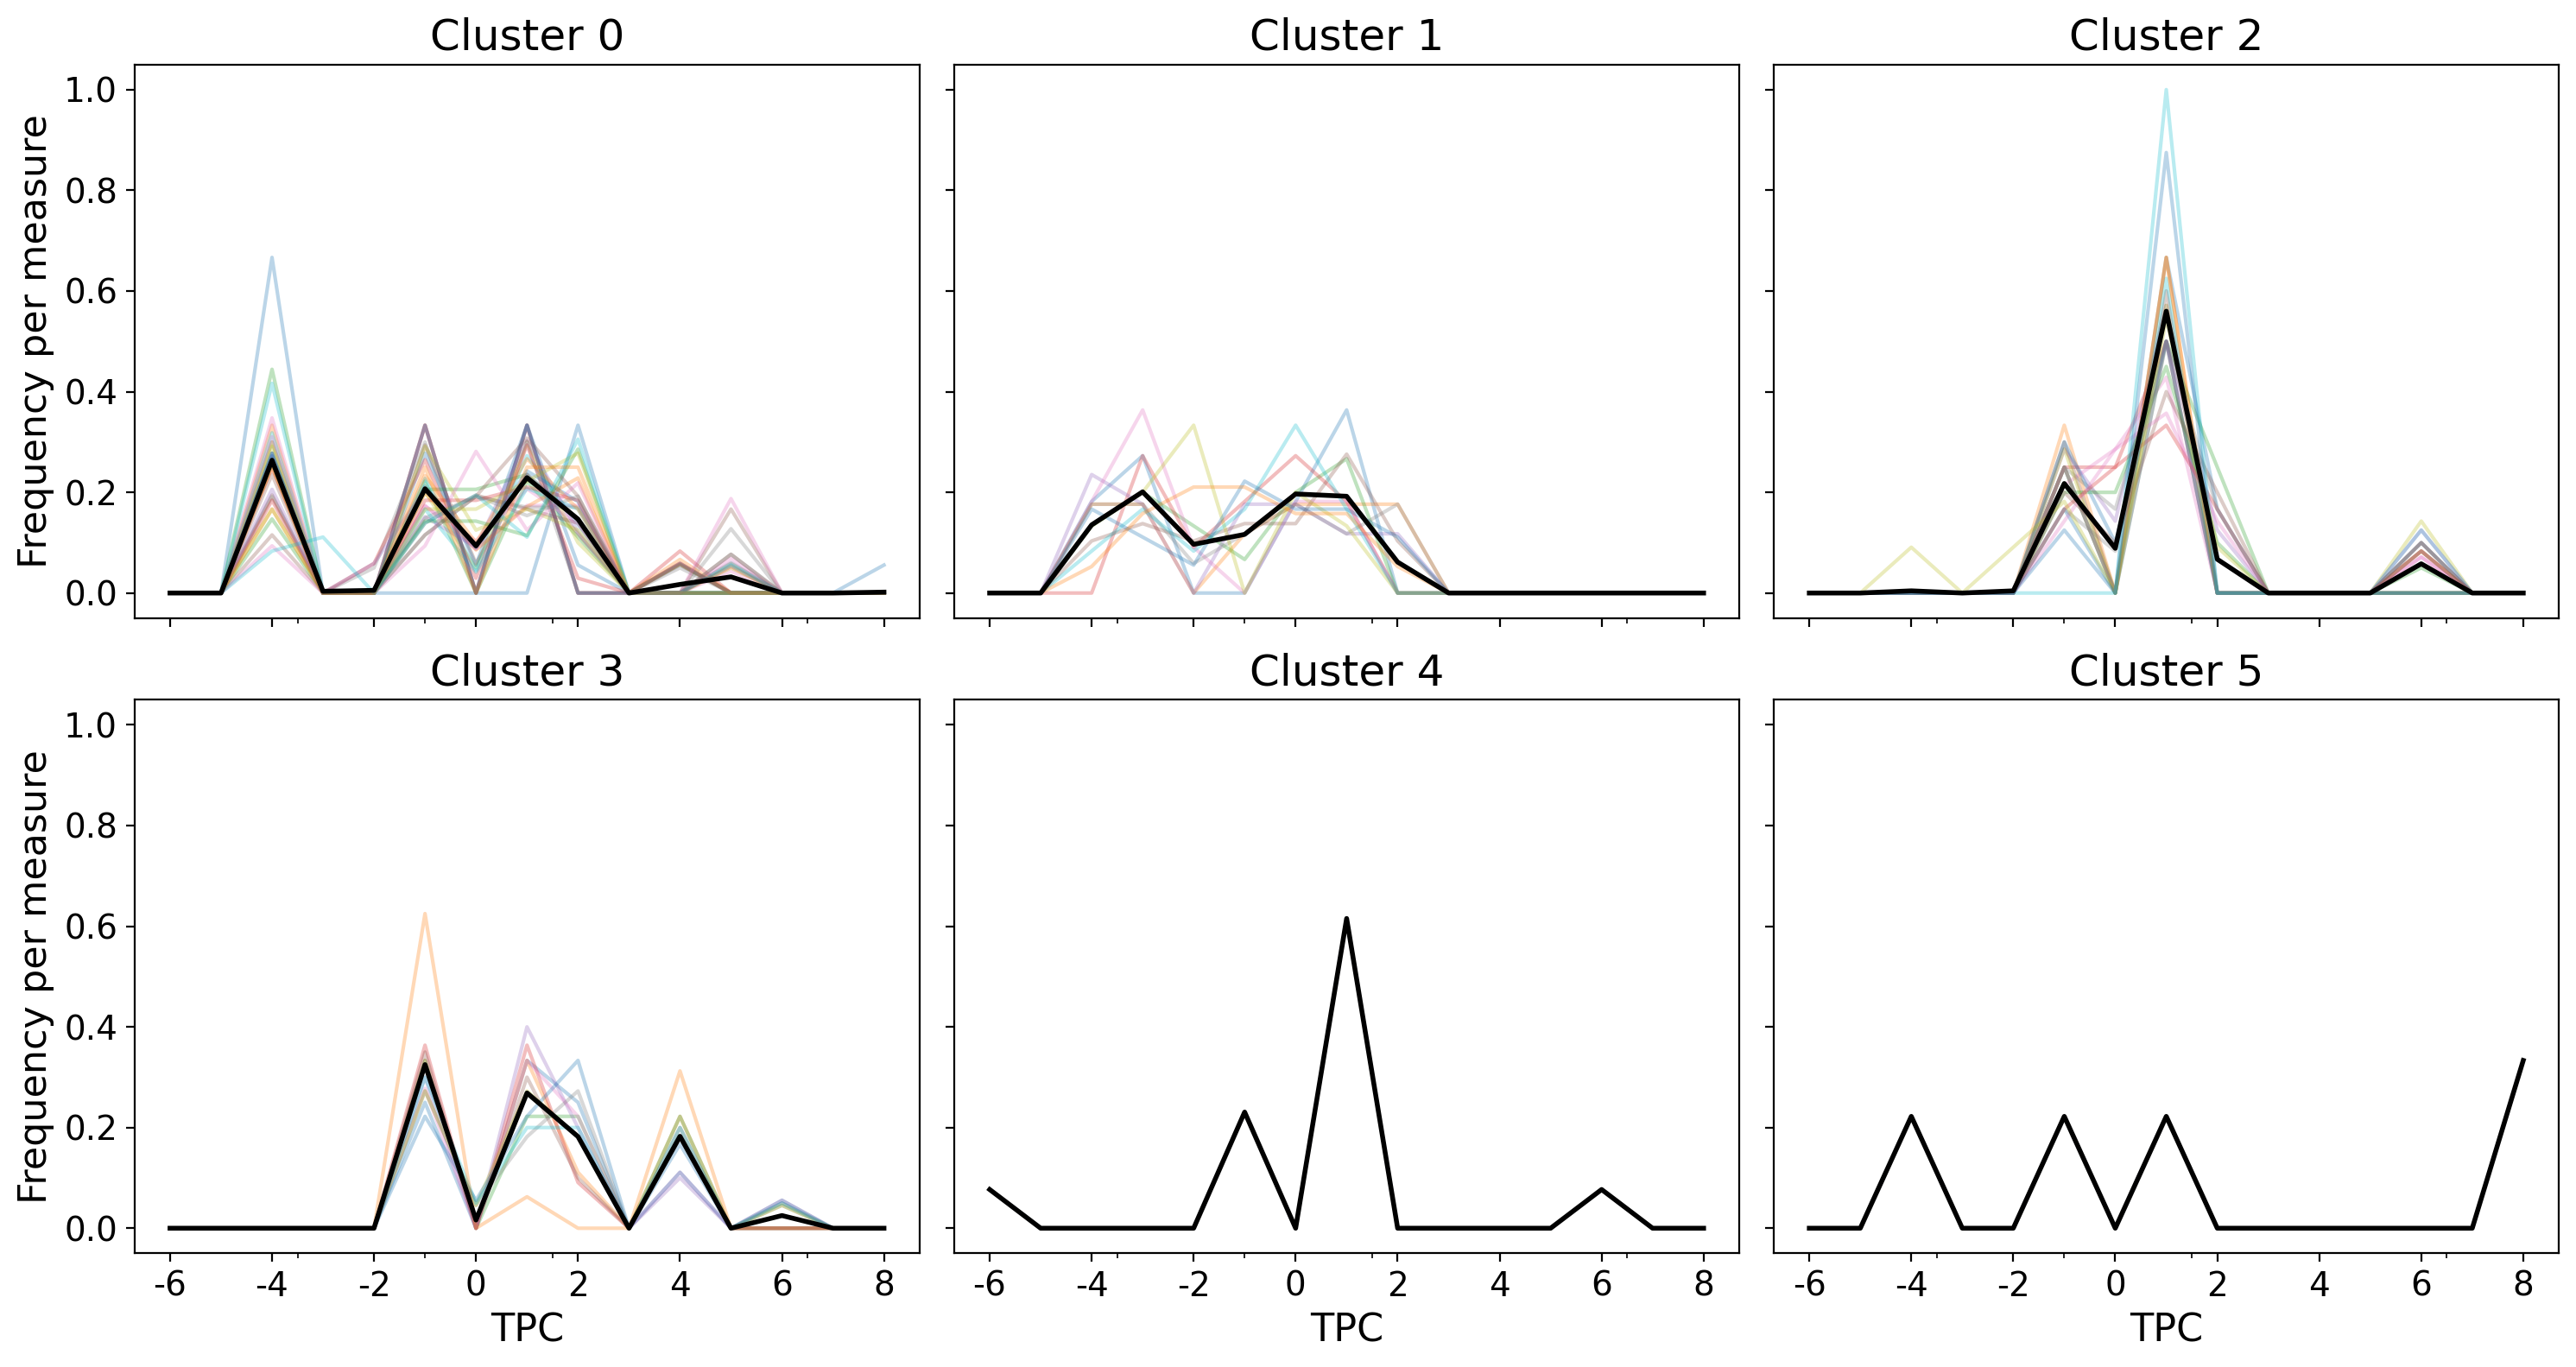

In [85]:
# Define number of clusters and grid layout
n_cols = 3
n_rows = (n_clusters + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to index easily

for key in range(n_clusters):
    ax = axes[key]
    
    subset = notes_no_dups[notes_no_dups['cluster'] == key]
    plot_df = subset.drop(columns=['cluster', 'recording_year', 'artist']).set_index('mc')
    
    plot_df.T.plot(ax=ax, legend=False, alpha=0.3)
    
    # Plot the average vector
    avg_vector = plot_df.mean(axis=0)
    avg_vector.plot(ax=ax, color="black", linewidth=2, label="Average")
    
    ax.set_title(f"Cluster {key}", fontsize = 18)
    ax.set_xlabel("TPC", fontsize=16)
    ax.set_ylabel("Frequency per measure", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)

# Remove unused subplots if n_clusters < n_rows*n_cols
for i in range(n_clusters, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig("all_clusters_grid.png", dpi=300)
plt.show()
